In [1]:
import pandas as pd 
df = pd.read_csv("/kaggle/input/equity-post-HCT-survival-predictions/train.csv")

# basic data exploration

In [2]:
# Shape and first few rows
print(df.shape)
print(df.head())

# Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Missing Values:\n", missing_values[missing_values > 0])

# Data types of columns
print(df.info())

# Summary statistics
print(df.describe())


(28800, 60)
   ID                       dri_score psych_disturb    cyto_score diabetes  \
0   0  N/A - non-malignant indication            No           NaN       No   
1   1                    Intermediate            No  Intermediate       No   
2   2  N/A - non-malignant indication            No           NaN       No   
3   3                            High            No  Intermediate       No   
4   4                            High            No           NaN       No   

   hla_match_c_high  hla_high_res_8          tbi_status arrhythmia  \
0               NaN             NaN              No TBI         No   
1               2.0             8.0  TBI +- Other, >cGy         No   
2               2.0             8.0              No TBI         No   
3               2.0             8.0              No TBI         No   
4               2.0             8.0              No TBI         No   

   hla_low_res_6  ...          tce_div_match donor_related  \
0            6.0  ...               

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


                 ID  hla_match_c_high  hla_high_res_8  hla_low_res_6  \
count  28800.000000      24180.000000    22971.000000   25530.000000   
mean   14399.500000          1.764516        6.876801       5.143322   
std     8313.988213          0.431941        1.564313       1.207757   
min        0.000000          0.000000        2.000000       2.000000   
25%     7199.750000          2.000000        6.000000       4.000000   
50%    14399.500000          2.000000        8.000000       6.000000   
75%    21599.250000          2.000000        8.000000       6.000000   
max    28799.000000          2.000000        8.000000       6.000000   

       hla_high_res_6  hla_high_res_10  hla_match_dqb1_high    hla_nmdp_6  \
count    23516.000000     21637.000000         23601.000000  24603.000000   
mean         5.109202         8.617230             1.736876      5.160346   
std          1.214162         1.905125             0.447687      1.203240   
min          0.000000         3.000000     

 # Target Variable Analysis

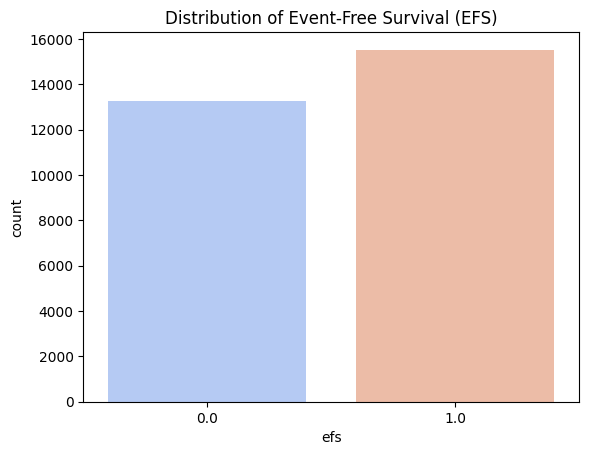

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


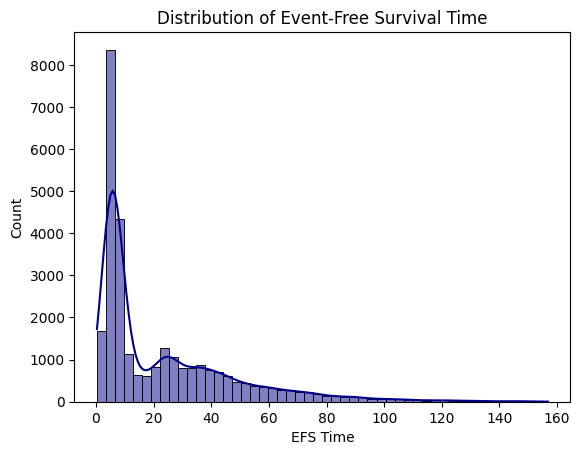

In [5]:
# Event-Free Survival (Binary Target)
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="efs", data=df, palette="coolwarm")
plt.title("Distribution of Event-Free Survival (EFS)")
plt.show()

# Distribution of EFS Time
sns.histplot(df["efs_time"], bins=50, kde=True, color="darkblue")
plt.title("Distribution of Event-Free Survival Time")
plt.xlabel("EFS Time")
plt.show()


# for efs:

Observation: 
The dataset has a fairly balanced distribution between patients who had event-free survival and those who did not.

# for efs time:

Observation: 
The majority of patients have a short event-free survival time, with a right-skewed distribution indicating a small 

subset of patients who experience long-term event-free survival.

 # Missing Values Analysis

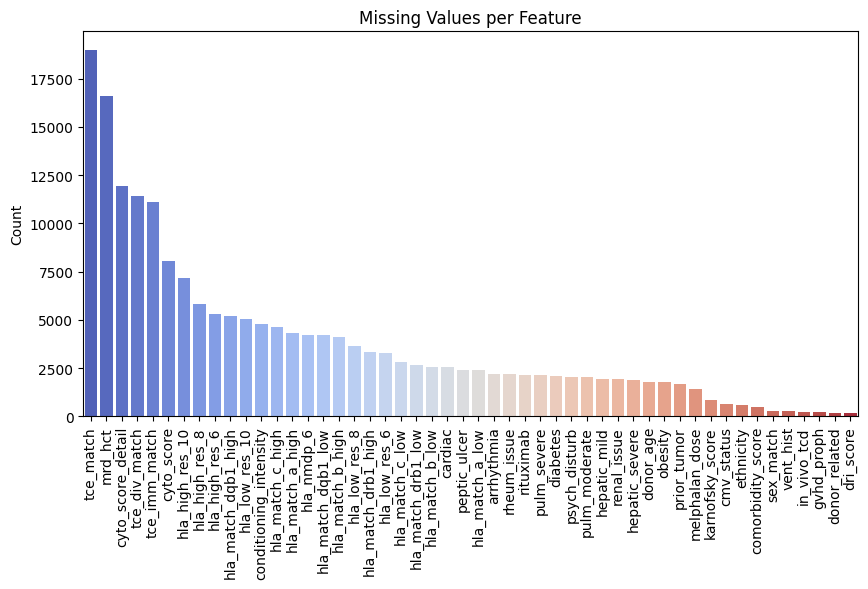

In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10,5))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='coolwarm')
plt.xticks(rotation=90)
plt.title("Missing Values per Feature")
plt.ylabel("Count")
plt.show()

Observation: 
Some features have missing values, which may require imputation or removal.

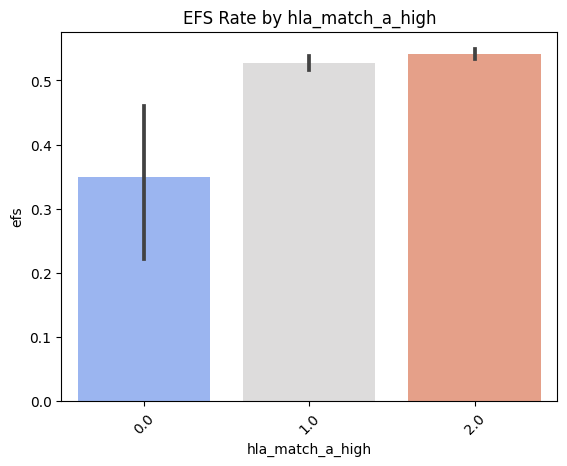

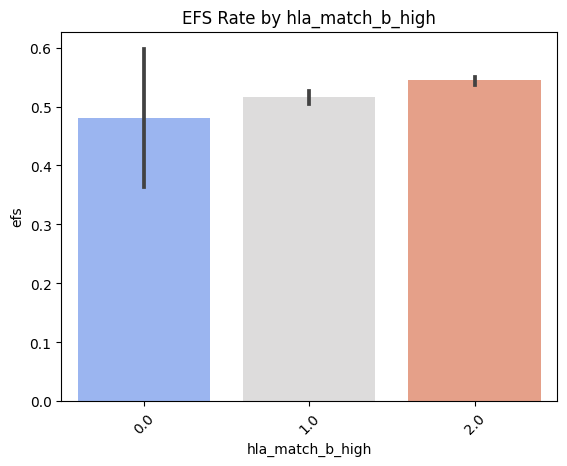

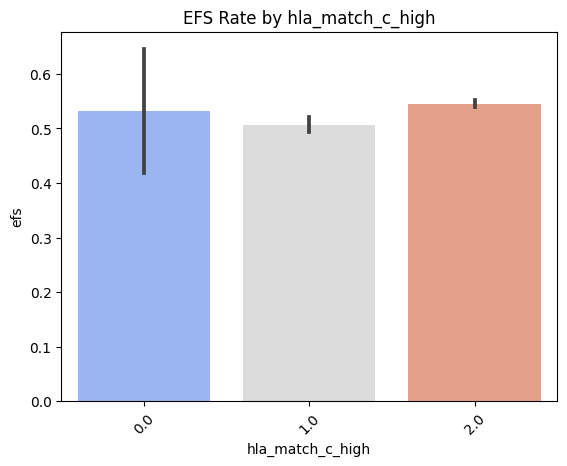

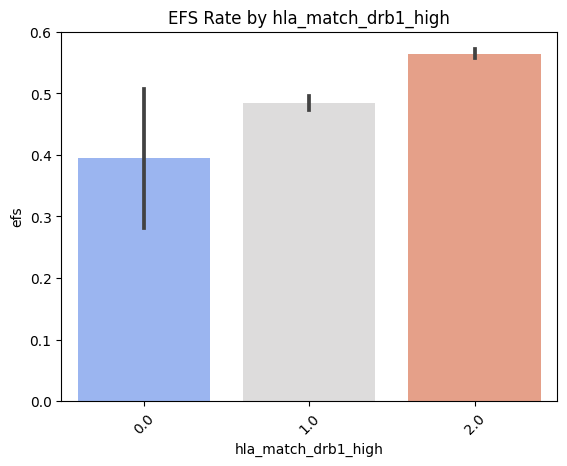

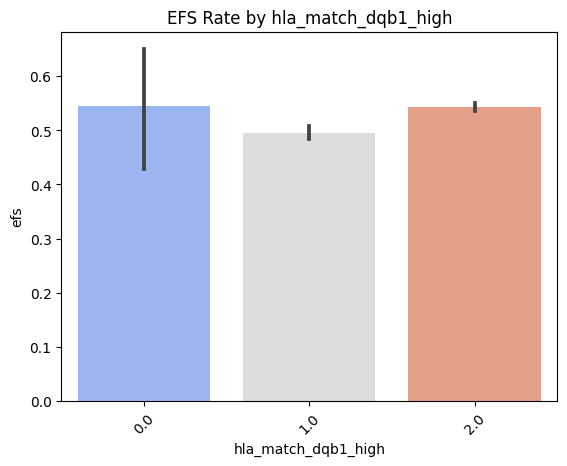

In [8]:
hla_cols = ["hla_match_a_high", "hla_match_b_high", "hla_match_c_high", "hla_match_drb1_high", "hla_match_dqb1_high"]

for col in hla_cols:
    sns.barplot(x=col, y="efs", data=df, palette="coolwarm")
    plt.xticks(rotation=45)
    plt.title(f"EFS Rate by {col}")
    plt.show()


Observation:
so in some cases there are some difference efs but in most the cases differences are not very significant

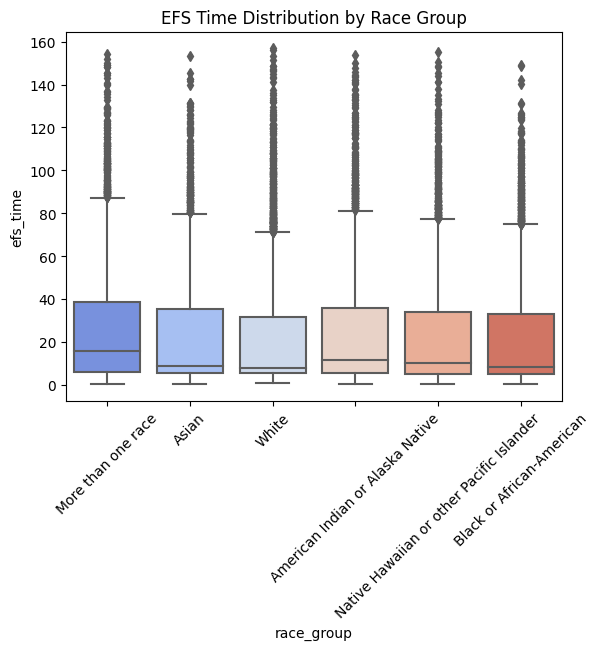

In [9]:
sns.boxplot(x="race_group", y="efs_time", data=df, palette="coolwarm")
plt.title("EFS Time Distribution by Race Group")
plt.xticks(rotation=45)
plt.show()


Observation:

The median EFS time appears relatively consistent across all race groups.

There is a high presence of outliers in all categories, indicating variability in survival times.

The interquartile range (IQR) suggests that most patients experience EFS times within a similar range, regardless of race.

The presence of numerous outliers above the upper whisker suggests that some individuals have significantly longer EFS times than the majority.

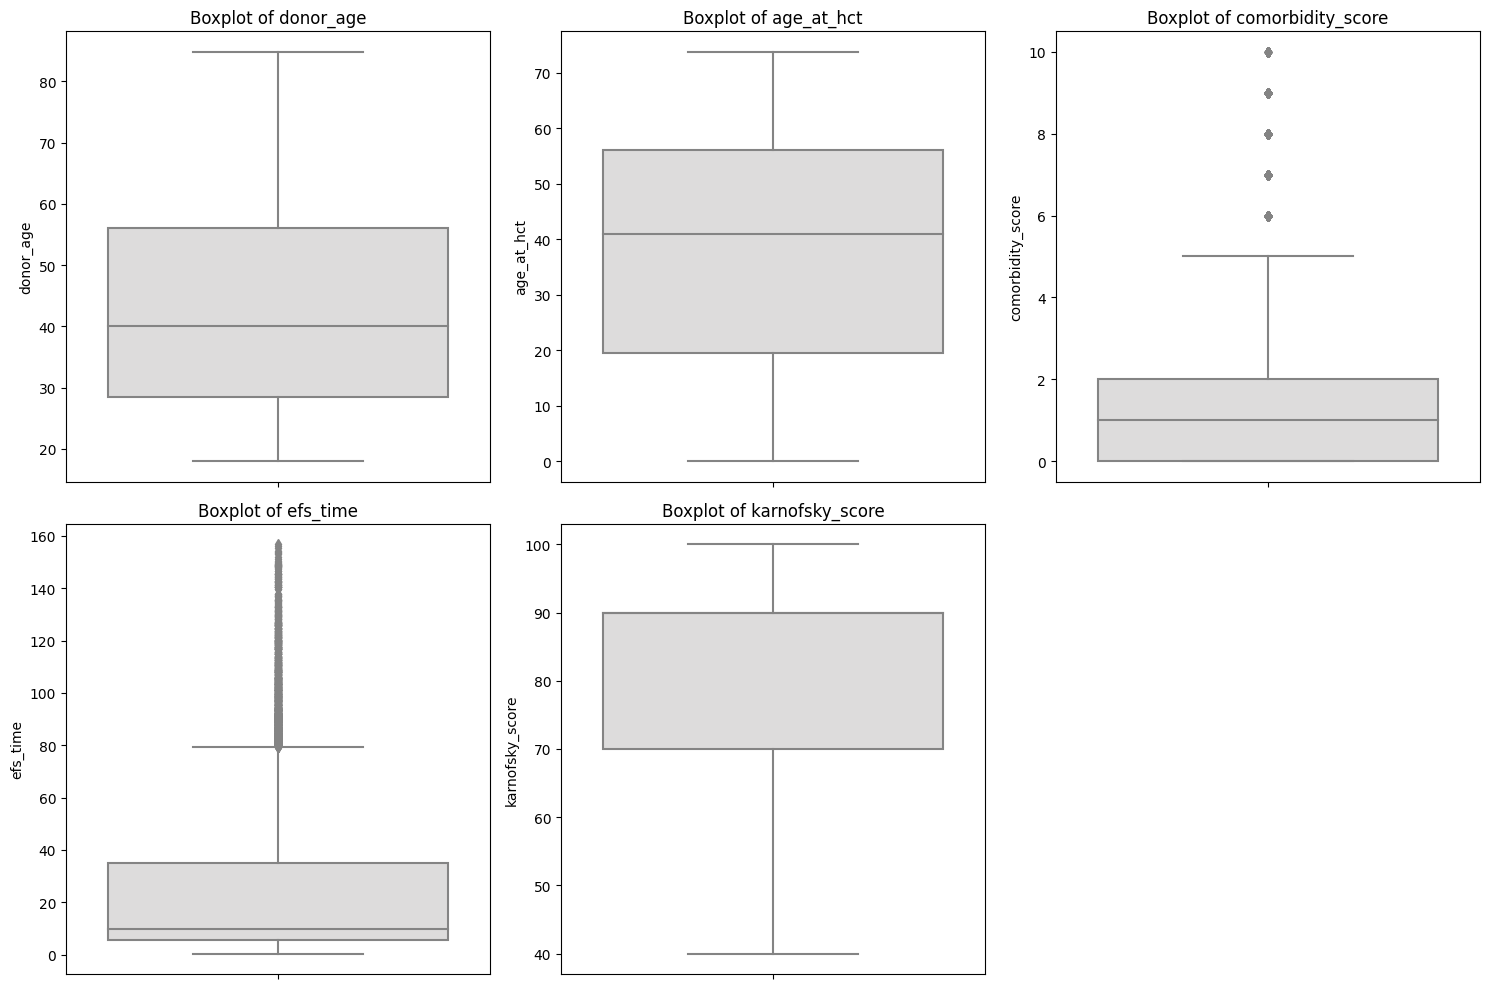

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["donor_age", "age_at_hct", "comorbidity_score", "efs_time", "karnofsky_score"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=col, data=df, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"Boxplot of {col}")

# Hide the unused subplot
for j in range(len(num_cols), len(axes)):  # Hide any extra subplot
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Observation:

Donor Age & Age at HCT: The distributions appear fairly normal, with the median age around 40–50 years. The age range varies significantly, with a few outliers.

Comorbidity Score: Most patients have low comorbidity scores, but a few outliers indicate significantly higher scores.
EFS Time: Similar to the previous visualization, EFS time has a high number of outliers, suggesting large variability in survival duration.

Karnofsky Score: Most patients have a high Karnofsky score (above 70), indicating good functional status.

# Principal Component Analysis (PCA)

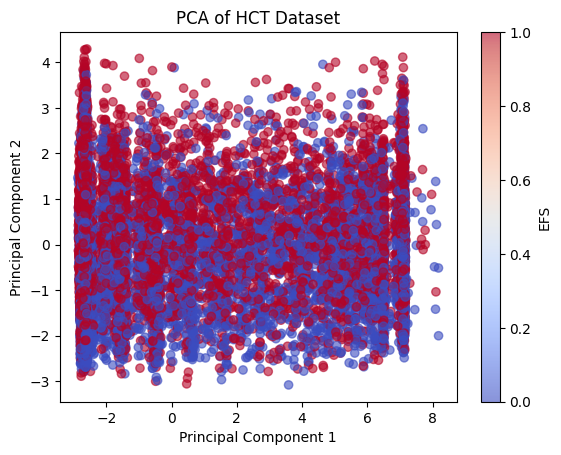

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop rows with missing values in features and target variables together
df_cleaned = df.dropna(subset=["efs", "efs_time"])  # Ensure target variables have no NaNs
features = df_cleaned.select_dtypes(include=[np.number]).drop(columns=["efs", "efs_time"])

# Drop rows with NaN in features to keep dimensions consistent
df_cleaned = df_cleaned.loc[features.dropna().index]  # Ensure same index
features = features.dropna()

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_scaled)

# Ensure color labels match the transformed data
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=df_cleaned["efs"].values, cmap="coolwarm", alpha=0.6)
plt.title("PCA of HCT Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="EFS")
plt.show()


Observation:

Above figure shows very high correlation between efs and efs_time.

# Clustering Analysis

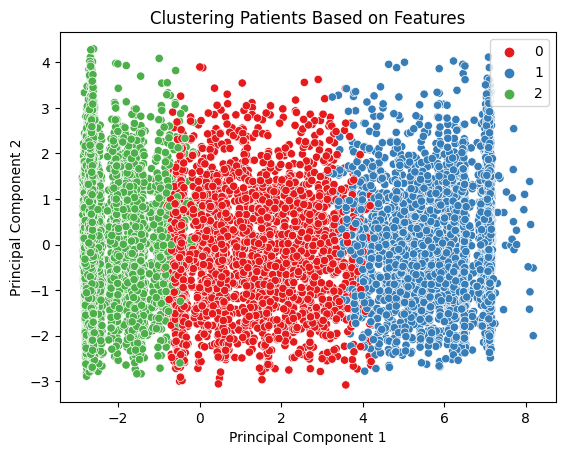

In [18]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Drop rows with missing values in features and target variables together
df_cleaned = df.dropna(subset=["efs", "efs_time"])  # Ensure target variables have no NaNs
features = df_cleaned.select_dtypes(include=[np.number]).drop(columns=["efs", "efs_time"])

# Drop rows with NaN in features to keep dimensions consistent
df_cleaned = df_cleaned.loc[features.dropna().index]  # Ensure same index
features = features.dropna()

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)  # Add `n_init` to avoid warning
df_cleaned["cluster"] = kmeans.fit_predict(features_scaled)  # Assign clusters to the cleaned dataframe

# PCA for visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_scaled)

# Plot PCA clusters
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=df_cleaned["cluster"], palette="Set1")
plt.title("Clustering Patients Based on Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


observation :
so it shows using efs time we can predict efs values were not completely overlaped